# 02 · Business Analysis: Answering the CEO & CMO

The clean dataset from notebook 01 is used to answer the four questions from the brief:

| # | Stakeholder question |
|---|---|
| Q1 | How did **revenue evolve month by month in 2011**? (to support forecasting) |
| Q2 | Which are the **top 10 countries by revenue and quantity**, excluding the UK? |
| Q3 | Who are the **top 10 customers by revenue**? |
| Q4 | Which **countries have the highest demand**, excluding the UK? (expansion opportunities) |

The same questions are answered visually in the Power BI report (`powerbi/`).

In [1]:
import calendar

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

from online_retail import (
    load_clean_data,
    load_raw_data,
    monthly_revenue,
    net_revenue_by_customer,
    revenue_by_country,
    top_customers,
)
from online_retail.plotting import (
    MUTED,
    PRIMARY,
    TEXT_SECONDARY,
    format_gbp,
    gbp_axis_formatter,
    plot_ranked_bars,
    save_figure,
    set_style,
)

set_style()
pd.set_option("display.float_format", "{:,.2f}".format)

sales = load_clean_data()

In [2]:
uk_share = sales.loc[sales["Country"] == "United Kingdom", "Revenue"].sum() / sales["Revenue"].sum()

pd.Series(
    {
        "Period": f"{sales['InvoiceDate'].min():%d %b %Y} – {sales['InvoiceDate'].max():%d %b %Y}",
        "Revenue": f"£{sales['Revenue'].sum():,.0f}",
        "Orders": f"{sales['InvoiceNo'].nunique():,}",
        "Identified customers": f"{sales['CustomerID'].nunique():,}",
        "Countries": sales["Country"].nunique(),
        "UK share of revenue": f"{uk_share:.0%}",
    },
    name="Key figures",
).to_frame()

,Key figures
Period,01 Dec 2010 – 09 Dec 2011
Revenue,"£10,666,685"
Orders,"20,726"
Identified customers,"4,339"
Countries,38
UK share of revenue,85%


The business is overwhelmingly domestic: **the UK accounts for ~85 % of revenue**. That's why the brief
leaves it out of Q2 and Q4, which are about international growth.

## Q1 · Monthly revenue in 2011

In [3]:
monthly_2011 = monthly_revenue(sales, year=2011)
monthly_2011["Revenue_per_Trading_Day"] = monthly_2011["Revenue"] / monthly_2011["Trading_Days"]
monthly_2011.index = [calendar.month_abbr[m] for m in monthly_2011.index]
monthly_2011

,Revenue,Orders,Trading_Days,Revenue_per_Trading_Day
Jan,"691,364.56",1120,24,"28,806.86"
Feb,"523,631.89",1126,24,"21,818.00"
Mar,"717,639.36",1531,27,"26,579.24"
Apr,"537,808.62",1318,21,"25,609.93"
May,"770,536.02",1731,25,"30,821.44"
Jun,"761,739.90",1576,26,"29,297.69"
Jul,"719,221.19",1540,26,"27,662.35"
Aug,"759,138.38",1407,26,"29,197.63"
Sep,"1,058,590.17",1896,26,"40,715.01"
Oct,"1,154,979.30",2129,26,"44,422.28"


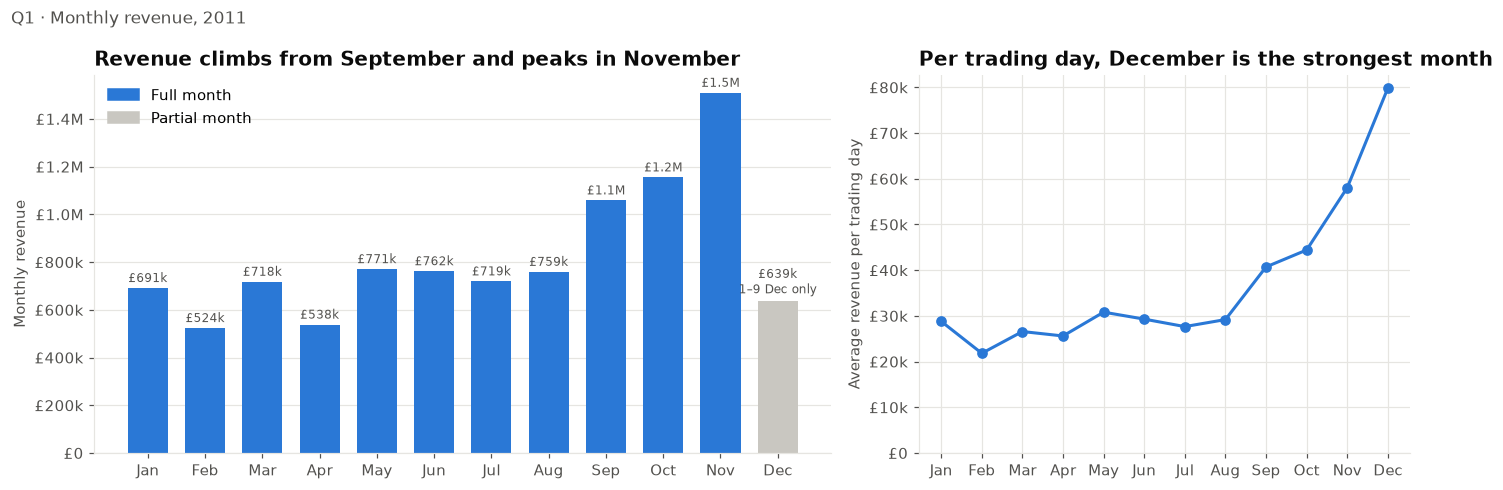

In [4]:
is_partial = monthly_2011.index == "Dec"
colors = [MUTED if partial else PRIMARY for partial in is_partial]

fig, (ax_total, ax_daily) = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [3, 2]})

ax_total.bar(monthly_2011.index, monthly_2011["Revenue"], color=colors, width=0.7)
ax_total.set_title("Revenue climbs from September and peaks in November")
ax_total.set_ylabel("Monthly revenue")
ax_total.yaxis.set_major_formatter(gbp_axis_formatter)
ax_total.grid(axis="x", visible=False)
bar_labels = [format_gbp(v) for v in monthly_2011["Revenue"]]
bar_labels[-1] += "\n1–9 Dec only"
ax_total.bar_label(ax_total.containers[0], labels=bar_labels, padding=2, fontsize=8, color=TEXT_SECONDARY)
ax_total.legend(
    handles=[Patch(color=PRIMARY, label="Full month"), Patch(color=MUTED, label="Partial month")],
    loc="upper left",
)

ax_daily.plot(monthly_2011.index, monthly_2011["Revenue_per_Trading_Day"], color=PRIMARY, marker="o", linewidth=2)
ax_daily.set_title("Per trading day, December is the strongest month")
ax_daily.set_ylabel("Average revenue per trading day")
ax_daily.yaxis.set_major_formatter(gbp_axis_formatter)
ax_daily.set_ylim(bottom=0)

fig.suptitle("Q1 · Monthly revenue, 2011", x=0.01, ha="left", fontsize=11, color=TEXT_SECONDARY)
fig.tight_layout()
save_figure(fig, "q1_monthly_revenue_2011")
plt.show()

In [5]:
h1 = monthly_2011.loc["Jan":"Jun", "Revenue"].mean()
sep_nov = monthly_2011.loc["Sep":"Nov", "Revenue"].mean()
print(f"Average monthly revenue Jan–Jun : £{h1:,.0f}")
print(f"Average monthly revenue Sep–Nov : £{sep_nov:,.0f} (+{sep_nov / h1 - 1:.0%})")

Average monthly revenue Jan–Jun : £667,120
Average monthly revenue Sep–Nov : £1,241,022 (+86%)


**Insights**
- Revenue is **flat from January to August** (≈ £0.5–0.8M per month), then **climbs sharply from September
  to November**, peaking at **£1.5M in November**, more than double the first-half monthly average,
  in line with a gift retailer's Christmas season.
- The December drop is **not a real decline**: the data stops on 9 December. Per trading day, December is
  the strongest month of the year (based on only 8 trading days, so treat it as an indication).
- **For forecasting:** plan stock, staff and marketing for a Q4 peak starting in September. Only one year
  is available, so this seasonality should be confirmed with more history before building a forecast model.

## Q2 · Top 10 countries by revenue (excluding the UK)

In [6]:
countries = revenue_by_country(sales, exclude=["United Kingdom"])
top_countries = countries.head(10).copy()

top_customer_revenue = (
    sales.dropna(subset=["CustomerID"])
    .groupby(["Country", "CustomerID"])["Revenue"].sum()
    .groupby(level="Country").max()
)
top_countries["Top_Customer_Share"] = top_customer_revenue / top_countries["Revenue"]
top_countries["Share_of_Intl_Revenue"] = top_countries["Revenue"] / countries["Revenue"].sum()

top_countries.style.format(
    {"Revenue": "£{:,.0f}", "Quantity": "{:,.0f}", "Top_Customer_Share": "{:.0%}", "Share_of_Intl_Revenue": "{:.1%}"}
)

,Revenue,Quantity,Customers,Orders,Top_Customer_Share,Share_of_Intl_Revenue
Country,,,,,,
Netherlands,"£285,446","200,937",9,95,98%,17.4%
EIRE,"£283,454","147,447",3,288,51%,17.3%
Germany,"£228,867","119,263",94,457,9%,13.9%
France,"£209,715","112,104",87,392,9%,12.8%
Australia,"£138,521","84,209",9,57,90%,8.4%
Spain,"£61,577","27,951",30,90,22%,3.8%
Switzerland,"£57,090","30,630",21,54,19%,3.5%
Belgium,"£41,196","23,237",25,98,13%,2.5%
Sweden,"£38,378","36,083",8,36,83%,2.3%


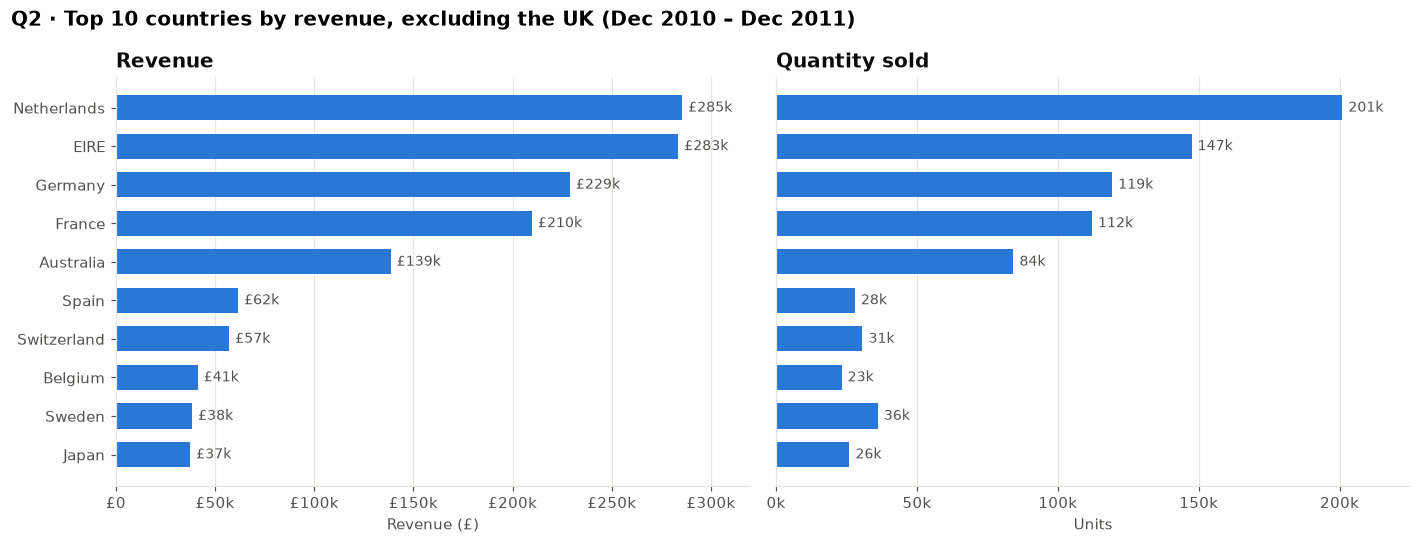

In [7]:
fig, (ax_revenue, ax_quantity) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

plot_ranked_bars(ax_revenue, top_countries["Revenue"], "Revenue", "Revenue (£)")
plot_ranked_bars(
    ax_quantity, top_countries["Quantity"], "Quantity sold", "Units",
    formatter=lambda v, _=None: f"{v / 1000:.0f}k",
)
ax_quantity.tick_params(axis="y", length=0)

fig.suptitle(
    "Q2 · Top 10 countries by revenue, excluding the UK (Dec 2010 – Dec 2011)",
    x=0.01, ha="left", fontsize=13, fontweight="bold",
)
fig.tight_layout()
save_figure(fig, "q2_top_countries")
plt.show()

**Insights**
- The **Netherlands, EIRE, Germany and France** make up over 60 % of international revenue. After them, there
  is a sharp drop (Australia is 5th, then every other country is under £62k).
- **Revenue concentration is a risk:** in the Netherlands, one customer generates almost all the revenue,
  and EIRE has just 3 customers (Australia and Sweden show the same pattern). These "markets" are really a handful of wholesale accounts. Losing one of
  them would wipe out most of the country's revenue.
- **Germany and France are the healthiest markets**: similar revenue, spread over ~90 customers each.
  They are the best base for international growth.
- Quantity and revenue follow the same ranking, with a few exceptions (Sweden sells high volume at a low
  average price).

## Q3 · Top 10 customers by revenue

Following the brief, customers are ranked on the clean dataset (**gross revenue**). But notebook 01 showed that
two very large orders were cancelled a few minutes after being placed. To check whether the ranking holds up,
it is compared with **net revenue** (sales minus cancellations and returns).

In [8]:
raw = load_raw_data()
net_revenue = net_revenue_by_customer(raw)

top_gross = top_customers(sales, n=10)
top_gross["Net_Revenue"] = net_revenue.reindex(top_gross.index)
top_gross["Cancelled_Share"] = 1 - top_gross["Net_Revenue"] / top_gross["Revenue"]
top_gross.style.format({"Revenue": "£{:,.0f}", "Net_Revenue": "£{:,.0f}", "Cancelled_Share": "{:.0%}"})

,Revenue,Orders,Country,Net_Revenue,Cancelled_Share
CustomerID,,,,,
14646,"£280,206",74,Netherlands,"£279,489",0%
18102,"£259,657",60,United Kingdom,"£256,438",1%
17450,"£194,551",46,United Kingdom,"£187,482",4%
16446,"£168,472",2,United Kingdom,£3,100%
14911,"£143,825",201,EIRE,"£132,573",8%
12415,"£124,915",21,Australia,"£123,725",1%
14156,"£117,380",55,EIRE,"£113,384",3%
17511,"£91,062",31,United Kingdom,"£88,125",3%
16029,"£81,025",63,United Kingdom,"£50,993",37%


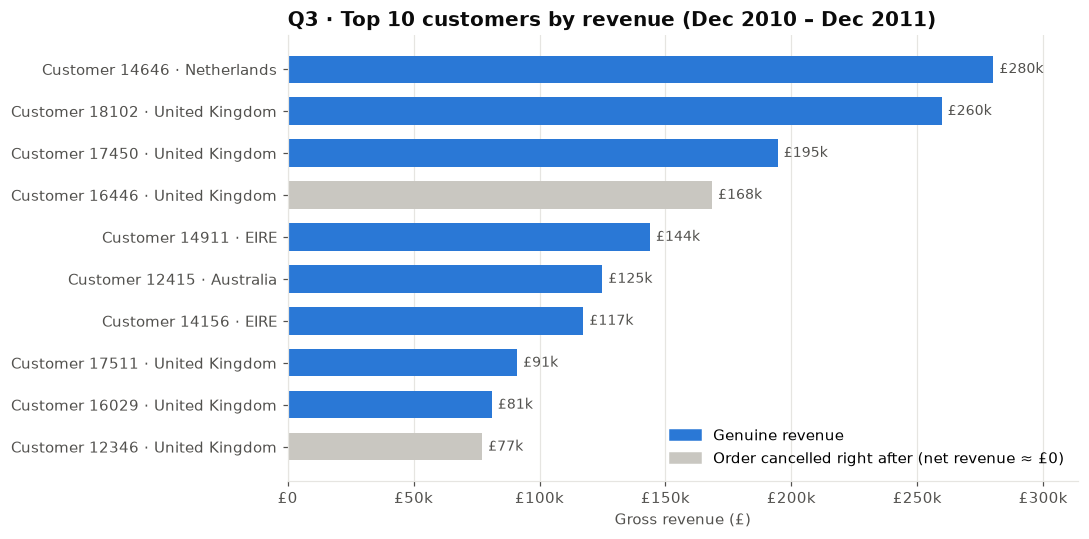

In [9]:
is_distorted = top_gross["Cancelled_Share"] > 0.5
labels = [f"Customer {cid} · {country}" for cid, country in zip(top_gross.index, top_gross["Country"])]
colors = [MUTED if distorted else PRIMARY for distorted in is_distorted]

fig, ax = plt.subplots(figsize=(10, 5))
plot_ranked_bars(
    ax, top_gross["Revenue"].set_axis(labels), "Q3 · Top 10 customers by revenue (Dec 2010 – Dec 2011)",
    "Gross revenue (£)", colors=colors,
)
ax.legend(
    handles=[Patch(color=PRIMARY, label="Genuine revenue"),
             Patch(color=MUTED, label="Order cancelled right after (net revenue ≈ £0)")],
    loc="lower right",
)
fig.tight_layout()
save_figure(fig, "q3_top_customers")
plt.show()

In [10]:
identified_revenue = sales.dropna(subset=["CustomerID"])["Revenue"].sum()
top_net = net_revenue.nlargest(10)

print(f"Customers ranked on gross revenue but net ≈ £0: {top_gross.index[is_distorted].tolist()}")
print(f"Share of identified revenue from the true top 10 (net): {top_net.sum() / identified_revenue:.1%}")
top_net.to_frame().style.format("£{:,.0f}")

Customers ranked on gross revenue but net ≈ £0: [16446, 12346]
Share of identified revenue from the true top 10 (net): 15.4%


,Net_Revenue
CustomerID,
14646,"£279,489"
18102,"£256,438"
17450,"£187,482"
14911,"£132,573"
12415,"£123,725"
14156,"£113,384"
17511,"£88,125"
16684,"£65,892"
13694,"£62,653"


**Insights**
- **Customers 16446 and 12346 are false positives.** Each placed a single huge order (80,995 and 74,215
  units) and cancelled it within minutes. Their net revenue is about £0. A dashboard built only on the brief's
  rules would tell the CMO to target them. The corrected top 10 (net revenue) replaces them with
  customers 13694 and 15311. Customer 16029 also had 37 % of their orders cancelled.
- The genuine top customers (14646 – Netherlands, 18102, 17450 – UK) each bring in **£190k–£280k**,
  more than most individual countries.
- The true top 10 represent **~15 % of identified revenue**, spread over 4,300+ customers. The business
  depends on a small group of high-value accounts plus a long tail of small buyers.
- **Recommendation:** set up a key-account program for the top ~10 customers (retention, dedicated pricing),
  and always rank customers on **net** revenue in the dashboard.

## Q4 · Demand by country (excluding the UK)

In [11]:
demand = countries.sort_values("Quantity", ascending=False)
demand["Share_of_Intl_Quantity"] = demand["Quantity"] / demand["Quantity"].sum()
demand["Cumulative_Share"] = demand["Share_of_Intl_Quantity"].cumsum()

top_demand = demand.head(15)
top_demand.style.format(
    {"Revenue": "£{:,.0f}", "Quantity": "{:,.0f}", "Share_of_Intl_Quantity": "{:.1%}", "Cumulative_Share": "{:.0%}"}
)

,Revenue,Quantity,Customers,Orders,Share_of_Intl_Quantity,Cumulative_Share
Country,,,,,,
Netherlands,"£285,446","200,937",9,95,21.7%,22%
EIRE,"£283,454","147,447",3,288,15.9%,38%
Germany,"£228,867","119,263",94,457,12.9%,50%
France,"£209,715","112,104",87,392,12.1%,63%
Australia,"£138,521","84,209",9,57,9.1%,72%
Sweden,"£38,378","36,083",8,36,3.9%,76%
Switzerland,"£57,090","30,630",21,54,3.3%,79%
Spain,"£61,577","27,951",30,90,3.0%,82%
Japan,"£37,416","26,016",8,19,2.8%,85%


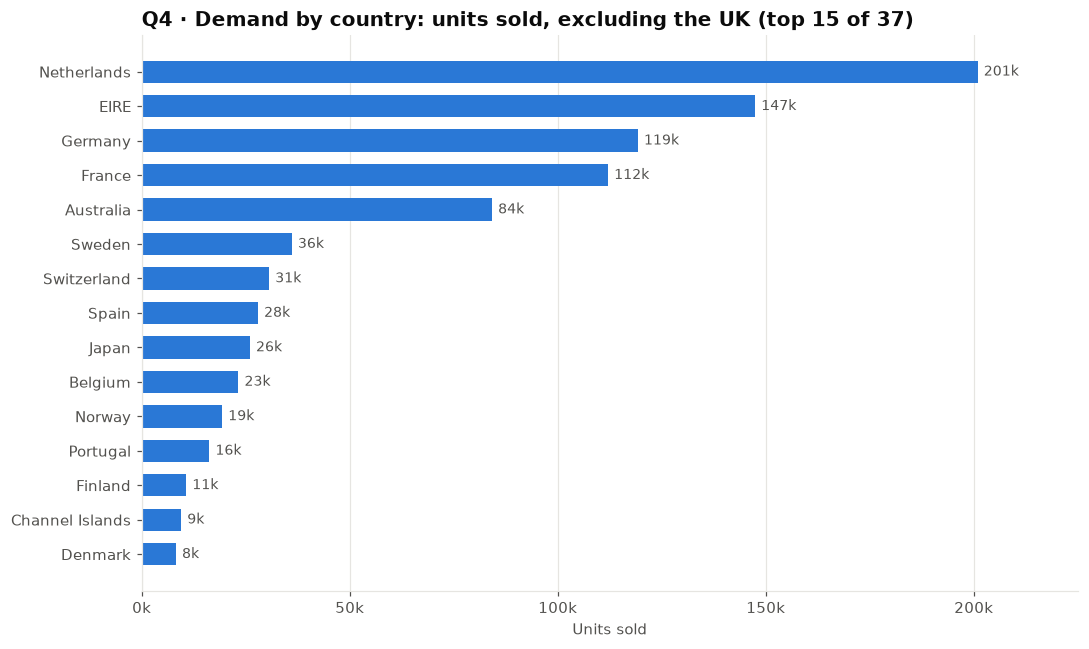

Top 5 countries = 72% of international units sold


In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_ranked_bars(
    ax, top_demand["Quantity"], f"Q4 · Demand by country: units sold, excluding the UK (top 15 of {len(demand)})",
    "Units sold", formatter=lambda v, _=None: f"{v / 1000:.0f}k",
)
fig.tight_layout()
save_figure(fig, "q4_demand_by_country")
plt.show()

print(f"Top 5 countries = {demand['Cumulative_Share'].iloc[4]:.0%} of international units sold")

**Insights**
- International demand is concentrated in **Western Europe**: the Netherlands, EIRE, Germany and France,
  with Australia as the only large market outside Europe.
- The top 5 countries account for **72 % of international volume**. The other 30+ countries sell
  only a few thousand units each.
- **Expansion recommendation:** **Germany and France** combine high demand with a broad customer base. They
  are the lowest-risk markets for localised marketing and logistics investment. The Netherlands and EIRE
  have high volume but depend on very few accounts, so the priority there is **retaining** those accounts
  rather than expansion.

## Conclusions

| Question | Answer |
|---|---|
| Q1 · Monthly revenue 2011 | Stable until August, then a strong Sep–Nov peak (Nov = £1.5M). The December "drop" is a partial month |
| Q2 · Top countries | Netherlands, EIRE, Germany, France lead, but NL and EIRE depend on 1–3 customers |
| Q3 · Top customers | 14646 (NL), 18102, 17450 lead. Two "top" customers are cancelled bulk orders, so rank on net revenue |
| Q4 · Demand | Concentrated in Western Europe. Germany & France are the best-balanced expansion targets |

**Limitations:** one year of history (seasonality not confirmed), 16 % of revenue from unidentified customers,
country is the customer's residence, and gross revenue includes postage and fees (~4 %). See notebook 01.

**Next steps:** a customer segmentation (RFM) to size the key-account program, and a monthly forecast
once more than one year of data is available.